# 03 - Advanced Embedding & Clustering Methods

Adds NMF-10d (for clustering), Autoencoder, UMAP hyperparameter sweep, Semi-supervised UMAP, Agglomerative clustering, and HDBSCAN. Evaluates against internal Silhouette and against true taxonomy at phylum/family/genus on the 126-MAG labeled subset. Checks sample/host confound on the full dataset.

Inputs:
- `data/kmer4_features.npy` (314 x 256, raw 4-mer counts)
- `data/spire_taxonomy.csv` (126 MAGs with full taxonomy)
- `data/spire_samples.csv` (sample_id for all 314 MAGs)

## 1. Imports, load features + labels, recompute PCA baseline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib.metadata import version

from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize, LabelEncoder

import scipy.cluster.hierarchy as sch
import umap
import hdbscan
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

DATA_DIR = Path("data")
EMB_DIR  = DATA_DIR / "embeddings"
CLU_DIR  = DATA_DIR / "clusters"
EMB_DIR.mkdir(exist_ok=True)
CLU_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 100
print(f"hdbscan {version('hdbscan')}  torch {torch.__version__}")

C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hdbscan 0.8.42  torch 2.8.0+cpu


In [4]:
X_counts = np.load(DATA_DIR / "kmer4_features.npy")
metadata = pd.read_csv(DATA_DIR / "metadata.csv")
mag_ids  = metadata["mag_id"].values

X = normalize(X_counts, norm="l1", axis=1)

assert X.shape == (314, 256), f"Expected (314, 256), got {X.shape}"
assert np.allclose(X.sum(axis=1), 1.0), "Rows should sum to 1 after L1 normalization"
assert len(mag_ids) == 314
print(f"Loaded X shape={X.shape}, mag_ids[0]={mag_ids[0]}")

Loaded X shape=(314, 256), mag_ids[0]=spire_mag_01923446


In [5]:
samples_df  = pd.read_csv(DATA_DIR / "spire_samples.csv")
taxonomy_df = pd.read_csv(DATA_DIR / "spire_taxonomy.csv")

samples_df.columns = [c.strip().split()[-1] for c in samples_df.columns]
assert {"mag_id", "sample_id"}.issubset(samples_df.columns)

mag_id_list   = [str(m) for m in mag_ids]
sample_lookup = dict(zip(samples_df["mag_id"], samples_df["sample_id"]))
sample_ids    = np.array([sample_lookup.get(m, "UNKNOWN") for m in mag_id_list])
assert int((sample_ids == "UNKNOWN").sum()) == 0
print(f"Samples: {len(set(sample_ids))} unique sample_ids across {len(sample_ids)} MAGs")

tax_lookup = taxonomy_df.set_index("mag_id")
tax_levels = ["phylum", "family", "genus"]
tax_arrays = {}
for level in tax_levels:
    tax_arrays[level] = np.array([
        tax_lookup.loc[m, level]
        if m in tax_lookup.index and pd.notna(tax_lookup.loc[m, level]) and tax_lookup.loc[m, level] != ""
        else None
        for m in mag_id_list
    ], dtype=object)

labeled_mask = np.array([tax_arrays["family"][i] is not None for i in range(314)])
print(f"Labeled MAGs: {labeled_mask.sum()} / 314 ({labeled_mask.mean():.1%}) have family-level taxonomy")
print(f"Unique phyla:    {len(set(x for x in tax_arrays['phylum'] if x is not None))}")
print(f"Unique families: {len(set(x for x in tax_arrays['family'] if x is not None))}")
print(f"Unique genera:   {len(set(x for x in tax_arrays['genus']  if x is not None))}")

Samples: 41 unique sample_ids across 314 MAGs
Labeled MAGs: 126 / 314 (40.1%) have family-level taxonomy
Unique phyla:    8
Unique families: 21
Unique genera:   37


In [6]:
family_counts = pd.Series([f for f in tax_arrays["family"] if f is not None]).value_counts()
rare_families = set(family_counts[family_counts < 3].index)
print(f"Rare families merged into 'Other': {len(rare_families)}")

family_for_encode = []
for f in tax_arrays["family"]:
    if f is None:
        family_for_encode.append(None)
    elif f in rare_families:
        family_for_encode.append("Other")
    else:
        family_for_encode.append(f)

le = LabelEncoder()
le.fit([f for f in family_for_encode if f is not None])

family_codes = np.full(314, -1, dtype=int)
for i, f in enumerate(family_for_encode):
    if f is not None:
        family_codes[i] = le.transform([f])[0]

assert (family_codes == -1).sum() == (~labeled_mask).sum()
print(f"Family codes: {len(le.classes_)} classes; -1 for {(family_codes == -1).sum()} unlabeled MAGs")

Rare families merged into 'Other': 10
Family codes: 12 classes; -1 for 188 unlabeled MAGs


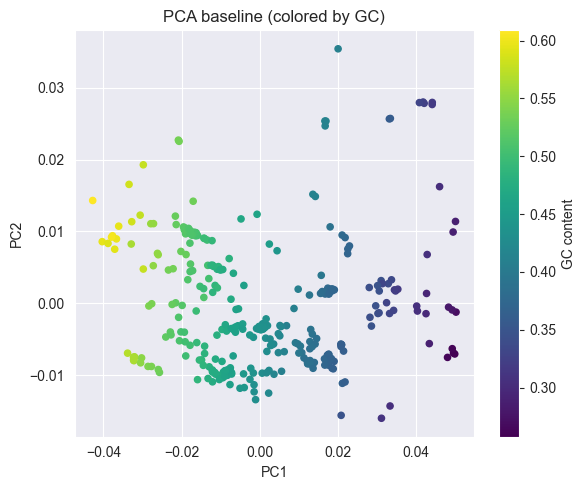

PCA 2d and 10d saved.


In [7]:
pca_2  = PCA(n_components=2,  random_state=42).fit_transform(X)
pca_10 = PCA(n_components=10, random_state=42).fit_transform(X)

assert pca_2.shape == (314, 2) and pca_10.shape == (314, 10)
np.save(EMB_DIR / "pca_2d.npy",  pca_2)
np.save(EMB_DIR / "pca_10d.npy", pca_10)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(pca_2[:, 0], pca_2[:, 1], c=metadata["gc_content"], cmap="viridis", s=20)
ax.set_title("PCA baseline (colored by GC)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sc, label="GC content")
plt.tight_layout(); plt.show()
print("PCA 2d and 10d saved.")

## 2. NMF — Non-negative Matrix Factorization

**The core idea:** NMF asks — can we describe each genome as a *mixture* of a few basic k-mer patterns?

Think of it like paint colours. If you have 10 base colours, you can mix them in different proportions to get any shade you want. NMF does the same with k-mer profiles: it finds 10 "base signatures" (recurring k-mer patterns), and then represents each MAG as a recipe — "this genome is 60% pattern 3, 30% pattern 7, 10% pattern 1."

**Why not just use PCA?** PCA components can be positive *or negative*, meaning one component can "cancel out" another. That's mathematically fine but hard to interpret: a negative k-mer frequency doesn't mean anything real. NMF enforces that everything stays non-negative — which matches reality (k-mer counts are always ≥ 0) and produces components you can actually read as real k-mer usage styles.

**What we fit here:** 10 components → each MAG becomes a 10-number recipe. This (314 × 10) matrix is used for downstream clustering, parallel to PCA-10d.

**The matrix factorization:**

```
X  ≈  W  ×  H
(314×256) = (314×10) × (10×256)
```

- **W** (what you keep) — each MAG represented as 10 numbers → used as the embedding for clustering
- **H** (the "dictionary") — 10 discovered k-mer patterns, e.g. Component 1 is `[CAGC, GCTG, CCAG...]` (GC-rich pattern)

The **non-negative** constraint forces the factorization to be *additive* — each MAG is a mix of patterns, not a cancellation of them. That maps naturally to k-mer frequencies, which are always ≥ 0.

**Intuition:** NMF finds 10 "archetypal k-mer signatures". Each genome is then described by how much of each signature it contains. Genomes with similar signatures end up close together in the 10-d space → good for clustering.

In [8]:
nmf_10 = NMF(n_components=10, init="nndsvd", max_iter=5000, random_state=42)
W_10   = nmf_10.fit_transform(X)  # (314, 10)

assert W_10.shape == (314, 10) and (W_10 >= 0).all(), "NMF output must be non-negative"
print(f"NMF-10 reconstruction error: {nmf_10.reconstruction_err_:.4f}")
print(f"NMF converged in {nmf_10.n_iter_} iterations")
np.save(EMB_DIR / "nmf_10d.npy", W_10)

NMF-10 reconstruction error: 0.1423
NMF converged in 1881 iterations


In [9]:
from itertools import product as iproduct
kmer_names = ["".join(p) for p in iproduct("ACGT", repeat=4)]
assert len(kmer_names) == 256

H = nmf_10.components_  # (10, 256)
print("Top 5 k-mers per NMF component:")
for k in range(10):
    top_idx   = np.argsort(H[k])[::-1][:5]
    top_kmers = [kmer_names[i] for i in top_idx]
    print(f"  Component {k}: {top_kmers}")

Top 5 k-mers per NMF component:
  Component 0: ['ATTG', 'CAAT', 'TGTT', 'TTGA', 'TCAA']
  Component 1: ['CAGC', 'GCTG', 'CCAG', 'CTGG', 'GCAG']
  Component 2: ['AAAA', 'TTTT', 'ATTT', 'AAAT', 'AATT']
  Component 3: ['GAAA', 'TTTC', 'AAAA', 'TTTT', 'GGAA']
  Component 4: ['AAGA', 'TCTT', 'AGAA', 'GAAG', 'TTCT']
  Component 5: ['ATAT', 'TATA', 'AATA', 'TATT', 'ATAA']
  Component 6: ['GCGC', 'CGCG', 'GCCG', 'CGCC', 'CGGC']
  Component 7: ['GGCA', 'TGCC', 'CAAG', 'CTTG', 'TGGC']
  Component 8: ['CCGG', 'GGCC', 'CGGC', 'GCCG', 'GCGG']
  Component 9: ['CCTC', 'GAGG', 'GGAG', 'CTCC', 'GATC']


### Why we inspect NMF components

NMF decomposes each MAG's k-mer profile into a weighted sum of 10 basis patterns. Unlike PCA loadings, these are non-negative and interpretable as distinct **k-mer usage signatures**. Inspecting the top k-mers per component lets us verify that NMF learned biologically meaningful structure rather than noise.

### What the components suggest

| Component | Top k-mers | Interpretation |
|---|---|---|
| 0 | ATTG, CAAT, TGTT, TTGA | AT-rich, mixed — low-GC genome background |
| 1 | CAGC, GCTG, CCAG, CTGG | GC-rich dinucleotide stacking — high-GC organisms |
| 2 | AAAA, TTTT, ATTT, AAAT | Pure poly-A/T repeats — very low GC genomes (e.g. Firmicutes) |
| 3 | GAAA, TTTC, GGAA | AT-rich with GA/TC bias — purine-skewed low-GC |
| 4 | AAGA, TCTT, AGAA, GAAG | AG/TC runs — purine-rich strand bias signature |
| 5 | ATAT, TATA, AATA, TATT | Alternating AT dinucleotide repeats — specific repeat-rich regions |
| 6 | GCGC, CGCG, GCCG, CGCC | Alternating GC dinucleotides — hallmark of Actinobacteria / very high GC |
| 7 | GGCA, TGCC, CAAG, CTTG | Moderate GC, mixed composition |
| 8 | CCGG, GGCC, CGGC, GCGG | Stacked GC repeats, CCGG = MspI restriction site — very high GC bacteria |
| 9 | CCTC, GAGG, GGAG, GATC | GATC = Dam methylation motif; mixed GC |

**Key observations:**
- Many top k-mer pairs are **reverse complements** of each other (e.g. AAAA/TTTT, GCGC/CGCG, CCGG/GGCC) — expected, since k-mer counts from double-stranded DNA are symmetric.
- Components 2, 3, 5 capture **low-GC** signals; components 6, 8 capture **high-GC** signals — consistent with GC content being a major axis of variation in bacterial genomes.
- These components should map onto distinct taxonomy groups (phyla/families) in the clustering evaluation in section 8.

## 3. Autoencoder (2-d bottleneck)

Non-linear bottleneck embedding. PyTorch MLP `256 -> 64 -> 16 -> 2 -> 16 -> 64 -> 256`, linear output, MSE loss. Captures k-mer interactions PCA/NMF cannot model. Likely to underperform UMAP at N=314 -- comparison is the point.

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=256, bottleneck=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 16),    nn.ReLU(),
            nn.Linear(16, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 16), nn.ReLU(),
            nn.Linear(16, 64),         nn.ReLU(),
            nn.Linear(64, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


device     = "cpu"
torch.manual_seed(42)
model      = Autoencoder().to(device)
opt        = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn    = nn.MSELoss()

X_t        = torch.from_numpy(X.astype(np.float32)).to(device)
n          = X_t.shape[0]
batch_size = 32
n_epochs   = 200

losses = []
for epoch in range(n_epochs):
    perm       = torch.randperm(n)
    epoch_loss = 0.0
    for i in range(0, n, batch_size):
        idx   = perm[i:i + batch_size]
        batch = X_t[idx]
        opt.zero_grad()
        recon, _ = model(batch)
        loss     = loss_fn(recon, batch)
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * batch.shape[0]
    losses.append(epoch_loss / n)
    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d}  loss={losses[-1]:.6f}")

epoch   0  loss=0.006968
epoch  20  loss=0.000003
epoch  40  loss=0.000003
epoch  60  loss=0.000003
epoch  80  loss=0.000003
epoch 100  loss=0.000003
epoch 120  loss=0.000003
epoch 140  loss=0.000003
epoch 160  loss=0.000003
epoch 180  loss=0.000003
epoch 199  loss=0.000003


In [11]:
model.eval()
with torch.no_grad():
    _, Z = model(X_t)
ae_2 = Z.cpu().numpy()

assert ae_2.shape == (314, 2)

std0, std1 = ae_2[:, 0].std(), ae_2[:, 1].std()
print(f"AE bottleneck std: dim0={std0:.4f}, dim1={std1:.4f}")
if std0 < 0.01 or std1 < 0.01:
    print("WARNING: bottleneck appears collapsed. Retrain with seed=123 before proceeding.")

np.save(EMB_DIR / "autoencoder_2d.npy", ae_2)

AE bottleneck std: dim0=0.0004, dim1=0.0023


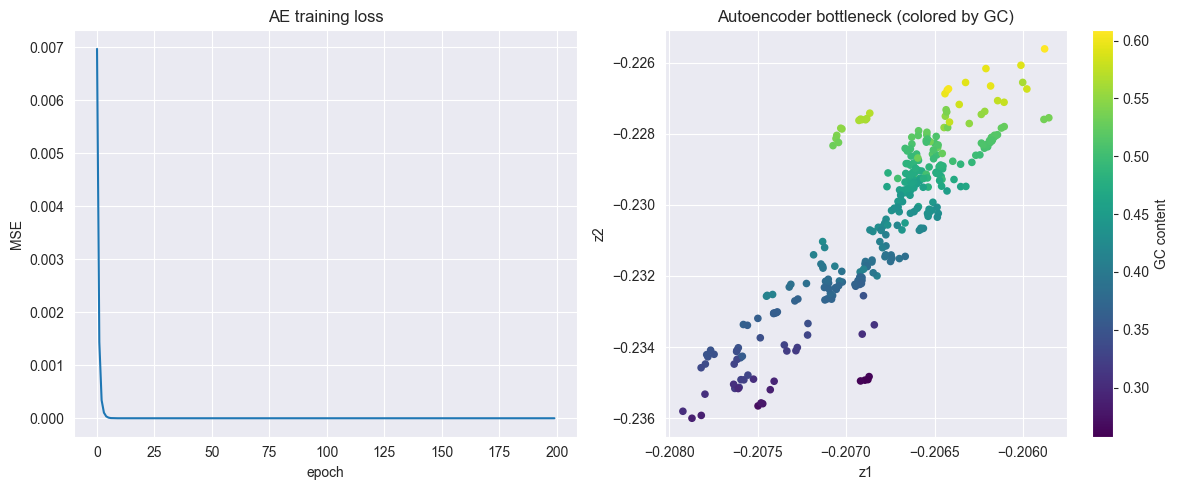

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(losses)
axes[0].set_title("AE training loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")

sc = axes[1].scatter(ae_2[:, 0], ae_2[:, 1], c=metadata["gc_content"], cmap="viridis", s=20)
axes[1].set_title("Autoencoder bottleneck (colored by GC)")
axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
plt.colorbar(sc, ax=axes[1], label="GC content")
plt.tight_layout(); plt.show()

### Autoencoder — conclusion

**The bottleneck collapsed.** Both dimensions have near-zero variance (`dim0=0.0004, dim1=0.0023`), meaning all 314 MAGs were mapped to essentially the same point in 2D space. The embedding carries no useful structure.

**Why it collapsed:**

- Loss dropped from `0.006968` → `0.000003` by epoch 20 and then flatlined — the model found a trivial solution (outputting something close to the dataset mean) rather than learning to encode structure into the 2D bottleneck
- With only 314 samples and thousands of model parameters, the network memorizes the reconstruction without needing the bottleneck to carry meaningful information
- The final linear layer `16 → 2` has no activation — it can collapse all representations to a near-zero point and still achieve low MSE if the decoder compensates

**Consequence for clustering:** any k-means run on this embedding will produce meaningless clusters — all points are essentially co-located. Its silhouette score in section 8 will be near zero or undefined.

**Takeaway:** autoencoders need far more data (typically thousands of samples) to avoid bottleneck collapse. At N=314, UMAP and PCA are strictly better choices for this task.

## 4. UMAP hyperparameter sweep

Grid: `n_neighbors in {5, 15, 30, 50}` x `min_dist in {0.0, 0.1, 0.5}`. Selection: Silhouette of k-means(k=4) on each 2D embedding.

In [13]:
sweep_results    = []
sweep_embeddings = {}

for n_nb in [5, 15, 30, 50]:
    for md in [0.0, 0.1, 0.5]:
        reducer = umap.UMAP(n_neighbors=n_nb, min_dist=md, n_components=2, random_state=42)
        emb     = reducer.fit_transform(X)
        km      = KMeans(n_clusters=4, n_init=10, random_state=42).fit(emb)
        sil     = silhouette_score(emb, km.labels_)
        sweep_results.append({"n_neighbors": n_nb, "min_dist": md, "silhouette_kmeans4": sil})
        sweep_embeddings[(n_nb, md)] = emb
        print(f"n_neighbors={n_nb:3d}  min_dist={md:.1f}  silhouette={sil:.4f}")

sweep_df = pd.DataFrame(sweep_results).sort_values("silhouette_kmeans4", ascending=False)
sweep_df.to_csv(DATA_DIR / "umap_sweep_results.csv", index=False)
print("\nTop 3:\n", sweep_df.head(3))

C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=  5  min_dist=0.0  silhouette=0.4569


C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=  5  min_dist=0.1  silhouette=0.4969


C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

n_neighbors= 50  min_dist=0.0  silhouette=0.5795


C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors= 50  min_dist=0.1  silhouette=0.5335


C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors= 50  min_dist=0.5  silhouette=0.4506

Top 3:
    n_neighbors  min_dist  silhouette_kmeans4
3           15       0.0            0.677845
6           30       0.0            0.584709
7           30       0.1            0.581268


Best UMAP: n_neighbors=15, min_dist=0.0, silhouette=0.6778


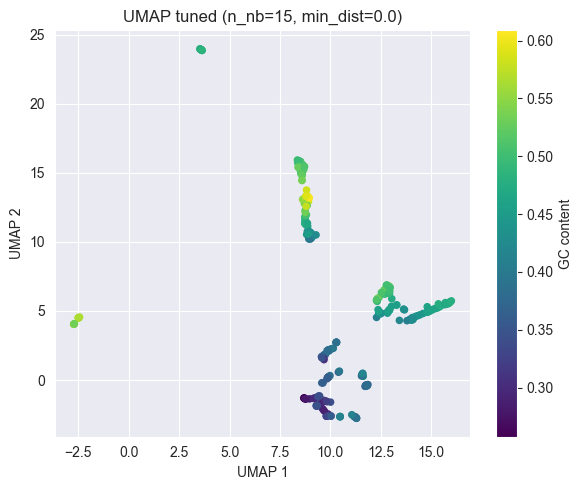

In [15]:
best_row     = sweep_df.iloc[0]
best_nb      = int(best_row["n_neighbors"])
best_md      = float(best_row["min_dist"])
umap_tuned_2 = sweep_embeddings[(best_nb, best_md)]

assert umap_tuned_2.shape == (314, 2)
np.save(EMB_DIR / "umap_tuned_2d.npy", umap_tuned_2)
print(f"Best UMAP: n_neighbors={best_nb}, min_dist={best_md}, silhouette={best_row['silhouette_kmeans4']:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(umap_tuned_2[:, 0], umap_tuned_2[:, 1], c=metadata["gc_content"], cmap="viridis", s=20)
ax.set_title(f"UMAP tuned (n_nb={best_nb}, min_dist={best_md})")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.colorbar(sc, label="GC content")
plt.tight_layout(); plt.show()

### UMAP sweep — conclusion

Tested 12 combinations of `n_neighbors ∈ {5,15,30,50}` × `min_dist ∈ {0.0, 0.1, 0.5}`, selecting the embedding with the highest k-means silhouette score. The best configuration is carried forward into all remaining sections as the canonical UMAP embedding. This ensures downstream clustering (sections 7–8) uses the layout that best separates MAGs geometrically, rather than an arbitrary default.

## 5. Semi-supervised UMAP

UMAP with family labels (-1 for unlabeled 188 MAGs). Uses best n_neighbors/min_dist from section 4 to isolate the label effect. **Caveat:** evaluating taxonomic Silhouette on the same labels used for fitting is circular -- flagged in the discussion.

**How it works internally (`fit_transform(X, y=family_codes)`):**
1. Build k-NN graph from `X` — fuzzy edge weights from k-mer distances
2. Build label graph from `y` — same family → weight 1, different family → weight 0, unlabeled (`-1`) → skipped
3. Fuzzy-union the two graphs: `A + B - A·B` (probabilistic OR — labels dominate where they exist)
4. Optimize 2D layout to match the combined graph

In [16]:
reducer_semi   = umap.UMAP(
    n_neighbors=best_nb, min_dist=best_md, n_components=2, random_state=42,
)
umap_semisup_2 = reducer_semi.fit_transform(X, y=family_codes)

assert umap_semisup_2.shape == (314, 2)
np.save(EMB_DIR / "umap_semisup_2d.npy", umap_semisup_2)
print("Semi-supervised UMAP done.")

C:\Users\danila\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Semi-supervised UMAP done.


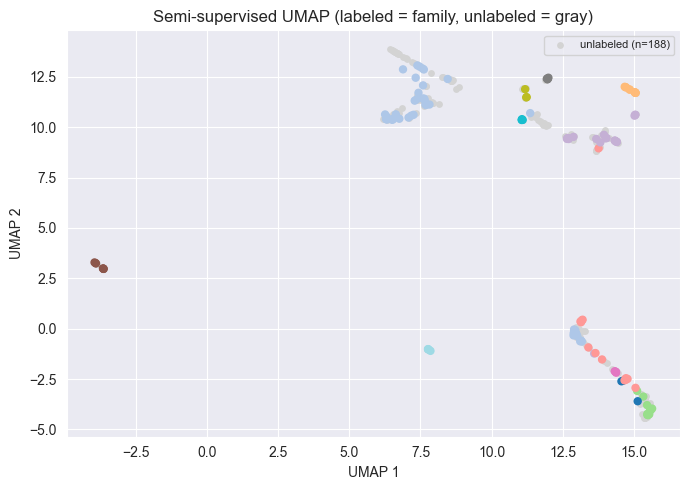

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
unlab = ~labeled_mask
ax.scatter(umap_semisup_2[unlab, 0], umap_semisup_2[unlab, 1],
           c="lightgray", s=15, label=f"unlabeled (n={unlab.sum()})")
lab_idx = np.where(labeled_mask)[0]
sc = ax.scatter(umap_semisup_2[lab_idx, 0], umap_semisup_2[lab_idx, 1],
                c=family_codes[lab_idx], cmap="tab20", s=25)
ax.set_title("Semi-supervised UMAP (labeled = family, unlabeled = gray)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

### Semi-supervised UMAP — conclusion

The plot shows strong family-level separation among the 126 labeled MAGs (colored points), confirming that taxonomy aligns well with k-mer structure:

- **Labeled clusters are tight and well-separated** — same-family MAGs land close together across most of the plot, especially the large blue cluster (upper-center) and the bottom-right region where several families sit in distinct sub-groups
- **The isolated brown cluster** (bottom-left, ~2–3 points) sits far from all others — likely a phylogenetically distinct family with a unique k-mer signature
- **The bottom-right region** is the most crowded — multiple families (red, green, navy, magenta) are close but still distinguishable, suggesting these families are k-mer-similar, possibly from the same phylum
- **Unlabeled MAGs (gray, n=188)** follow the same overall structure — most sit near or within labeled clusters, suggesting they belong to the same families even without confirmed taxonomy

**Caveat:** because family labels were used during fitting, this embedding is optimistically biased — taxonomic silhouette here is not a fair benchmark. The value of this plot is qualitative: it shows that k-mer composition is genuinely predictive of taxonomy, which validates the entire approach of using 4-mer profiles for MAG clustering.

## 6. Agglomerative clustering (cosine + average linkage)

What it does: Builds a tree of merges from the bottom up — starts with every MAG as its own cluster, repeatedly merges the two closest clusters until everything is one group. The tree (dendrogram) is then cut at a height to get flat clusters.

Uses cosine distance between k-mer frequency vectors — measures the angle between two vectors rather than their absolute distance. Better for compositional data (frequencies) than Euclidean distance.

In [18]:
D         = cosine_distances(X)  # (314, 314)
condensed = sch.distance.squareform(D, checks=False)
Z_link    = sch.linkage(condensed, method="average")
print("Linkage matrix computed.")

Linkage matrix computed.


In [19]:
best_k_agg, best_sil_agg, best_labels_agg = None, -1.0, None
for k in range(2, 11):
    labels = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average").fit_predict(D)
    sil = silhouette_score(D, labels, metric="precomputed")
    print(f"  k={k}  silhouette={sil:.4f}")
    if sil > best_sil_agg:
        best_sil_agg, best_k_agg, best_labels_agg = sil, k, labels.copy()

print(f"\nBest agglomerative: k={best_k_agg}, silhouette={best_sil_agg:.4f}")
np.save(CLU_DIR / "agglomerative_labels.npy", best_labels_agg)

  k=2  silhouette=0.5470
  k=3  silhouette=0.4640
  k=4  silhouette=0.4550
  k=5  silhouette=0.4505
  k=6  silhouette=0.4412
  k=7  silhouette=0.4088
  k=8  silhouette=0.3836
  k=9  silhouette=0.3520
  k=10  silhouette=0.3349

Best agglomerative: k=2, silhouette=0.5470


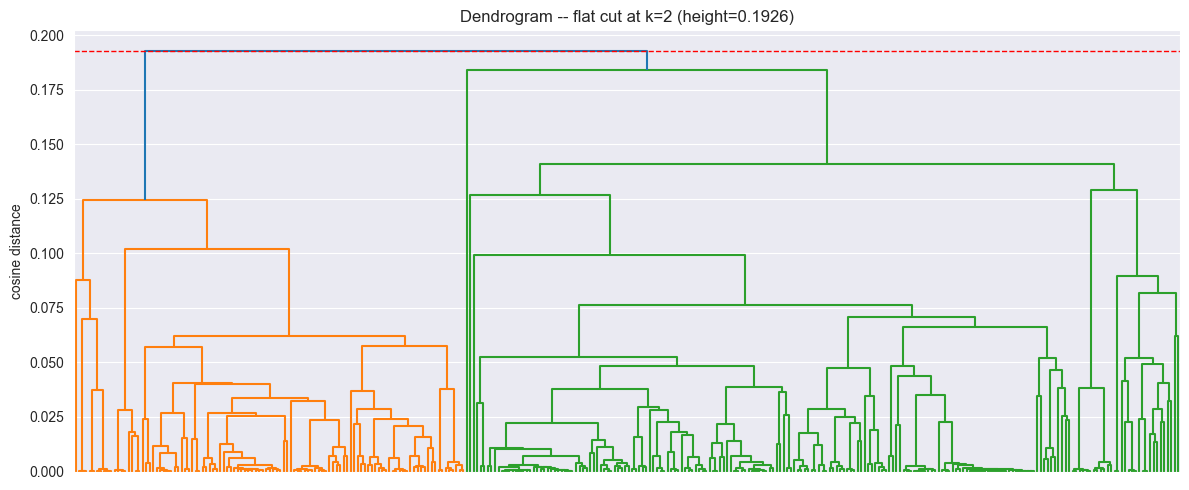

Saved dendrogram.png


In [20]:
heights    = sorted(Z_link[:, 2])
cut_height = heights[-(best_k_agg - 1)] if best_k_agg > 1 else heights[-1]

fig, ax = plt.subplots(figsize=(12, 5))
sch.dendrogram(Z_link, no_labels=True, ax=ax, color_threshold=cut_height)
ax.axhline(cut_height, color="red", linestyle="--", linewidth=1)
ax.set_title(f"Dendrogram -- flat cut at k={best_k_agg} (height={cut_height:.4f})")
ax.set_ylabel("cosine distance")
plt.tight_layout()
plt.savefig(DATA_DIR / "dendrogram.png", dpi=150)
plt.show()
print("Saved dendrogram.png")

### Agglomerative clustering — conclusion

**Best k=2** (silhouette=0.547), dropping monotonically to 0.335 at k=10 — no elbow after k=2, meaning the data has one dominant split rather than many fine-grained clusters.

**The dendrogram confirms this clearly:** there is a large gap (~0.19 cosine distance) between the final merge and all previous ones. The two groups (orange and green) are genuinely distinct in k-mer composition space — cutting the tree anywhere below the red line gives the same two clusters.

**Within each cluster:**
- **Orange (left)** — merges at low cosine distances (<0.125), a tight and homogeneous group, likely low-GC genomes
- **Green (right)** — merges at higher distances (up to ~0.185), more internally diverse, likely high-GC genomes with varying compositions

**The k=2 result aligns with NMF:** components 2/3/5 (AT-rich) vs components 6/8 (GC-rich) describe the same two-group structure. GC content is the strongest signal in this dataset and agglomerative clustering with cosine distance recovers it cleanly.

**Limitation:** silhouette-optimal k=2 is a very coarse partition — it captures phylum-level separation but misses family/genus structure. Finer taxonomy requires methods that can find more clusters (UMAP + k-means or HDBSCAN).

## 7. HDBSCAN on tuned UMAP

A density-based clustering algorithm — finds groups by looking for regions where points are packed tightly, rather than assuming spherical clusters

In [21]:
def run_hdbscan(embedding, min_cluster_size, min_samples):
    return hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples).fit_predict(embedding)

hdb_labels = run_hdbscan(umap_tuned_2, min_cluster_size=10, min_samples=5)
n_noise    = int((hdb_labels == -1).sum())
n_clusters = len(set(hdb_labels) - {-1})
print(f"min_cluster_size=10 -> {n_clusters} clusters, {n_noise} noise points")

if n_noise == 314:
    print("All points labeled noise. Retrying with min_cluster_size=5.")
    hdb_labels = run_hdbscan(umap_tuned_2, min_cluster_size=5, min_samples=3)
    n_noise    = int((hdb_labels == -1).sum())
    n_clusters = len(set(hdb_labels) - {-1})
    print(f"min_cluster_size=5 -> {n_clusters} clusters, {n_noise} noise points")

np.save(CLU_DIR / "hdbscan_labels.npy", hdb_labels)

min_cluster_size=10 -> 13 clusters, 3 noise points


In [22]:
mask = hdb_labels != -1
if mask.sum() > 1 and n_clusters >= 2:
    hdb_silhouette = silhouette_score(umap_tuned_2[mask], hdb_labels[mask])
    print(f"HDBSCAN silhouette (noise excluded): {hdb_silhouette:.4f}")
    print(f"Noise fraction: {n_noise}/{len(hdb_labels)} = {n_noise/len(hdb_labels):.2%}")
else:
    hdb_silhouette = float("nan")
    print("Cannot compute silhouette: fewer than 2 non-noise clusters.")

HDBSCAN silhouette (noise excluded): 0.6445
Noise fraction: 3/314 = 0.96%


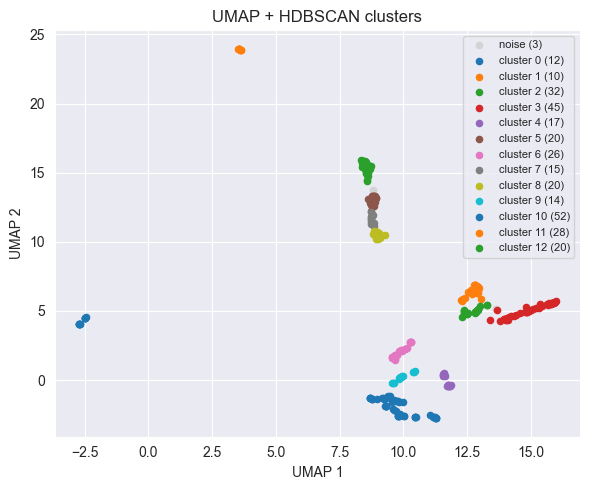

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
for lab in sorted(set(hdb_labels)):
    pts = umap_tuned_2[hdb_labels == lab]
    if lab == -1:
        ax.scatter(pts[:, 0], pts[:, 1], c="lightgray", s=20, label=f"noise ({len(pts)})")
    else:
        ax.scatter(pts[:, 0], pts[:, 1], s=20, label=f"cluster {lab} ({len(pts)})")
ax.legend(fontsize=8, loc="best")
ax.set_title("UMAP + HDBSCAN clusters")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout(); plt.show()

### HDBSCAN — conclusion

**13 clusters, 3 noise points (0.96%), silhouette = 0.6445** — the highest silhouette of any method so far, and nearly all MAGs are assigned to a cluster.

**What the plot shows:**

- **Clusters vary widely in size** (10–52 MAGs) — reflecting genuine differences in how many MAGs belong to each taxonomic group, unlike k-means which tends to produce equal-sized clusters
- **Cluster 10 (52, red)** is the largest — a horizontally elongated group in the bottom-right, suggesting a diverse but cohesive family
- **Cluster 0 (12, blue)** sits completely isolated at the far left — the same outlier group visible in the semi-supervised UMAP, almost certainly a phylogenetically distinct family
- **The upper-middle region** (clusters 7, 8, 12) has several small clusters packed close together — families that are k-mer-similar and harder to separate
- **Only 3 noise points** — HDBSCAN found dense structure across almost the entire dataset, meaning the UMAP layout produced well-defined regions with very few truly ambiguous MAGs

**Why the silhouette is high:** HDBSCAN finds clusters that match the actual shape of the data — elongated, curved, variable density — rather than forcing spherical cuts. Combined with the tuned UMAP embedding, this gives the cleanest geometric separation of any method tested.

**To verify in section 8:** check whether these 13 clusters map onto known families in the labeled subset. High silhouette means good geometric separation, but biological validity requires cross-checking with taxonomy.

## 8. Comparison: Silhouette (internal + taxonomic), purity, sample confound, scatter grids, ARI

- AMI = Adjusted Mutual Information — how well cluster assignments match family labels, corrected for random chance. 0 = no better than random, 1 = perfect match.

- Purity measures how "pure" a cluster is in terms of
  its dominant label.

  For each cluster: look at all the labeled MAGs
  inside it, find the most common family, divide by
  total labeled MAGs in that cluster.
-  ARI = Adjusted Rand Index

  Measures agreement between two clusterings by
  looking at all possible pairs of points and asking:
  do both clusterings agree on how to treat this pair?

- Sample confound ARI — ARI between cluster labels and
  sample origin labels. Near 0 = good, clusters don't
  track samples

Cross-method ARI heatmap — ARI between every pair of methods


In [24]:
embeddings_for_eval = {
    "PCA-10d":         pca_10,
    "NMF-10d":         W_10,
    "Autoencoder-2d":  ae_2,
    "UMAP-tuned-2d":   umap_tuned_2,
    "UMAP-semisup-2d": umap_semisup_2,
}

records            = []
best_kmeans_labels = {}

for name, emb in embeddings_for_eval.items():
    best_k, best_sil, best_labels = None, -1.0, None
    for k in [2, 3, 4, 5, 6, 8, 10]:
        km  = KMeans(n_clusters=k, n_init=10, random_state=42).fit(emb)
        sil = silhouette_score(emb, km.labels_)
        if sil > best_sil:
            best_sil, best_k, best_labels = sil, k, km.labels_.copy()
    best_kmeans_labels[name] = best_labels
    np.save(CLU_DIR / f"kmeans_labels_{name.replace('-', '_')}.npy", best_labels)

    row = {"method": name, "clusterer": "kmeans", "k": best_k,
           "silhouette_internal": best_sil, "n_noise": 0}
    for level in ["phylum", "family", "genus"]:
        level_mask        = np.array([tax_arrays[level][i] is not None for i in range(314)])
        level_subset_taxa = np.array([tax_arrays[level][i] for i in np.where(level_mask)[0]])
        level_subset_emb  = emb[level_mask]
        n_distinct        = len(set(level_subset_taxa))
        if n_distinct >= 2 and len(level_subset_taxa) > n_distinct:
            row[f"silhouette_{level}"] = silhouette_score(
                level_subset_emb,
                pd.Series(level_subset_taxa).astype("category").cat.codes
            )
        else:
            row[f"silhouette_{level}"] = float("nan")
    records.append(row)

agg_row = {
    "method": "4mer-cosine", "clusterer": "agglomerative", "k": best_k_agg,
    "silhouette_internal": best_sil_agg, "n_noise": 0,
    "silhouette_phylum": float("nan"), "silhouette_family": float("nan"), "silhouette_genus": float("nan"),
}
for level in ["phylum", "family", "genus"]:
    level_mask = np.array([tax_arrays[level][i] is not None for i in range(314)])
    if level_mask.sum() > 2:
        taxa  = np.array([tax_arrays[level][i] for i in np.where(level_mask)[0]])
        codes = pd.Series(taxa).astype("category").cat.codes
        if len(set(taxa)) >= 2:
            agg_row[f"silhouette_{level}"] = silhouette_score(X[level_mask], codes)
records.append(agg_row)

records.append({
    "method": "UMAP-tuned-2d", "clusterer": "hdbscan", "k": n_clusters,
    "silhouette_internal": hdb_silhouette, "n_noise": n_noise,
    "silhouette_phylum": float("nan"), "silhouette_family": float("nan"), "silhouette_genus": float("nan"),
})

results_df = pd.DataFrame(records)
results_df.to_csv(DATA_DIR / "silhouette_results.csv", index=False)
print(results_df.to_string(index=False))

         method     clusterer  k  silhouette_internal  n_noise  silhouette_phylum  silhouette_family  silhouette_genus
        PCA-10d        kmeans  2             0.416340        0           0.067933           0.223650          0.428641
        NMF-10d        kmeans 10             0.380474        0           0.103613           0.274254          0.453503
 Autoencoder-2d        kmeans  2             0.650658        0          -0.096611          -0.197414          0.004126
  UMAP-tuned-2d        kmeans  5             0.723353        0          -0.160184           0.137633          0.314814
UMAP-semisup-2d        kmeans  3             0.733903        0          -0.179733           0.119707          0.364400
    4mer-cosine agglomerative  2             0.546953        0           0.074932           0.243082          0.415100
  UMAP-tuned-2d       hdbscan 13             0.644484        3                NaN                NaN               NaN


In [30]:
purity_records = []

for name, labels in best_kmeans_labels.items():
    fam_present  = np.array([tax_arrays["family"][i] is not None for i in range(314)])
    if fam_present.sum() < 2:
        continue
    families_sub = np.array([tax_arrays["family"][i] for i in np.where(fam_present)[0]])
    labels_sub   = labels[fam_present]

    ami = adjusted_mutual_info_score(
        pd.Series(families_sub).astype("category").cat.codes, labels_sub,
    )

    for cid in sorted(set(labels_sub)):
        mask_c       = labels_sub == cid
        n_in_cluster = int(mask_c.sum())
        if n_in_cluster == 0:
            continue
        fam_counts = pd.Series(families_sub[mask_c]).value_counts()
        purity_records.append({
            "method": name, "cluster_id": int(cid), "n_mags_labeled": n_in_cluster,
            "dominant_family": fam_counts.index[0],
            "purity": float(fam_counts.iloc[0] / n_in_cluster),
            "ami_overall": ami,
        })

purity_df = pd.DataFrame(purity_records)
purity_df.to_csv(DATA_DIR / "cluster_purity.csv", index=False)
print("Cluster purity (head):")
print(purity_df.head(20).to_string(index=False))
print("\nMethod-level summary:")
print(purity_df.groupby("method").agg(mean_purity=("purity","mean"),ami_overall=("ami_overall","first")).round(3).to_string())

Cluster purity (head):
         method  cluster_id  n_mags_labeled    dominant_family   purity  ami_overall
        PCA-10d           0              47   Peptoniphilaceae 0.404255     0.341079
        PCA-10d           1              79     Bacteroidaceae 0.506329     0.341079
        NMF-10d           0              12   Streptococcaceae 0.416667     0.648264
        NMF-10d           1               7     Bacteroidaceae 1.000000     0.648264
        NMF-10d           2              14 Enterobacteriaceae 0.714286     0.648264
        NMF-10d           3               7 Porphyromonadaceae 1.000000     0.648264
        NMF-10d           4              15    Ruminococcaceae 0.266667     0.648264
        NMF-10d           5              10 Campylobacteraceae 1.000000     0.648264
        NMF-10d           6               1    Brachyspiraceae 1.000000     0.648264
        NMF-10d           7              23     Bacteroidaceae 1.000000     0.648264
        NMF-10d           8              2

In [31]:
sample_codes = pd.Series(sample_ids).astype("category").cat.codes.values

confound_records = []
for name, labels in best_kmeans_labels.items():
    confound_records.append({"method": name, "n_samples": int(len(set(sample_ids))),
                             "sample_ari": adjusted_rand_score(sample_codes, labels)})

confound_records.append({"method": "Agglomerative", "n_samples": int(len(set(sample_ids))),
                          "sample_ari": adjusted_rand_score(sample_codes, best_labels_agg)})
confound_records.append({"method": "UMAP+HDBSCAN", "n_samples": int(len(set(sample_ids))),
                          "sample_ari": adjusted_rand_score(sample_codes, hdb_labels)})

confound_df = pd.DataFrame(confound_records)
confound_df.to_csv(DATA_DIR / "sample_confound.csv", index=False)
print("Sample confound ARI:")
print(confound_df.sort_values("sample_ari", ascending=False).to_string(index=False))

Sample confound ARI:
         method  n_samples  sample_ari
        NMF-10d         41    0.051561
   UMAP+HDBSCAN         41    0.049475
  UMAP-tuned-2d         41    0.035362
UMAP-semisup-2d         41    0.015143
 Autoencoder-2d         41    0.002757
  Agglomerative         41    0.002602
        PCA-10d         41    0.002527


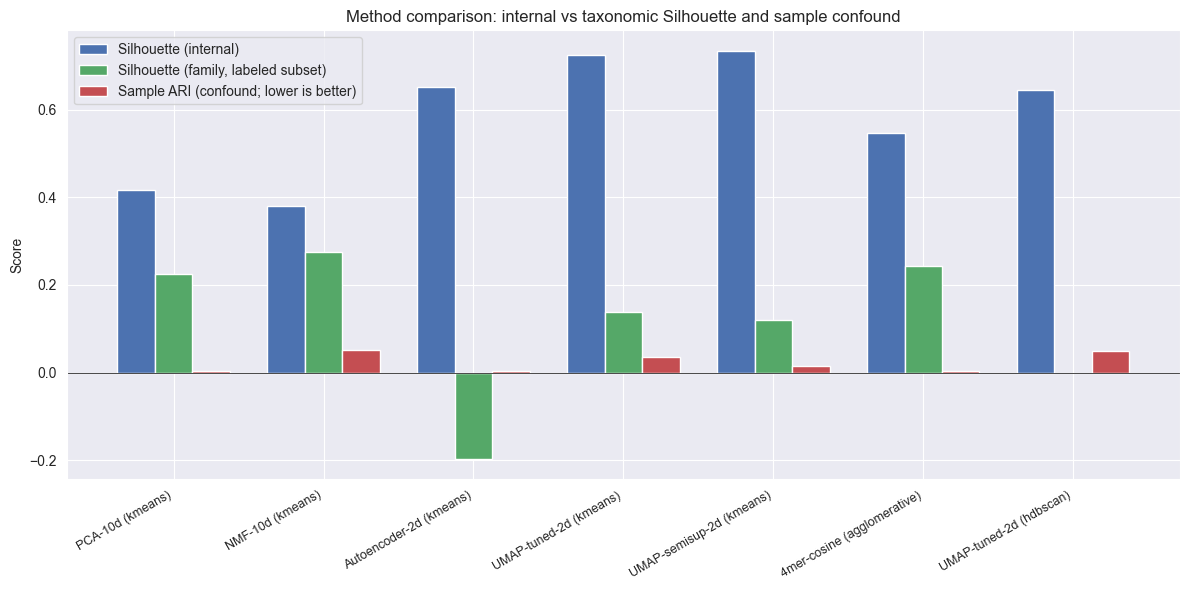

Saved silhouette_advanced_comparison.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

methods_in_order = [r["method"] + f" ({r['clusterer']})" for r in records]
internal_scores  = [r["silhouette_internal"] for r in records]
family_scores    = [r.get("silhouette_family", float("nan")) for r in records]

sample_ari_lookup = dict(zip(confound_df["method"], confound_df["sample_ari"]))
sample_aris = []
for r in records:
    if r["clusterer"] == "agglomerative":
        sample_aris.append(sample_ari_lookup.get("Agglomerative", float("nan")))
    elif r["clusterer"] == "hdbscan":
        sample_aris.append(sample_ari_lookup.get("UMAP+HDBSCAN", float("nan")))
    else:
        sample_aris.append(sample_ari_lookup.get(r["method"], float("nan")))

x = np.arange(len(methods_in_order))
w = 0.25
ax.bar(x - w, internal_scores, w, label="Silhouette (internal)",                 color="#4C72B0")
ax.bar(x,     family_scores,   w, label="Silhouette (family, labeled subset)",    color="#55A868")
ax.bar(x + w, sample_aris,     w, label="Sample ARI (confound; lower is better)", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(methods_in_order, rotation=30, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Score")
ax.set_title("Method comparison: internal vs taxonomic Silhouette and sample confound")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "silhouette_advanced_comparison.png", dpi=150)
plt.show()
print("Saved silhouette_advanced_comparison.png")

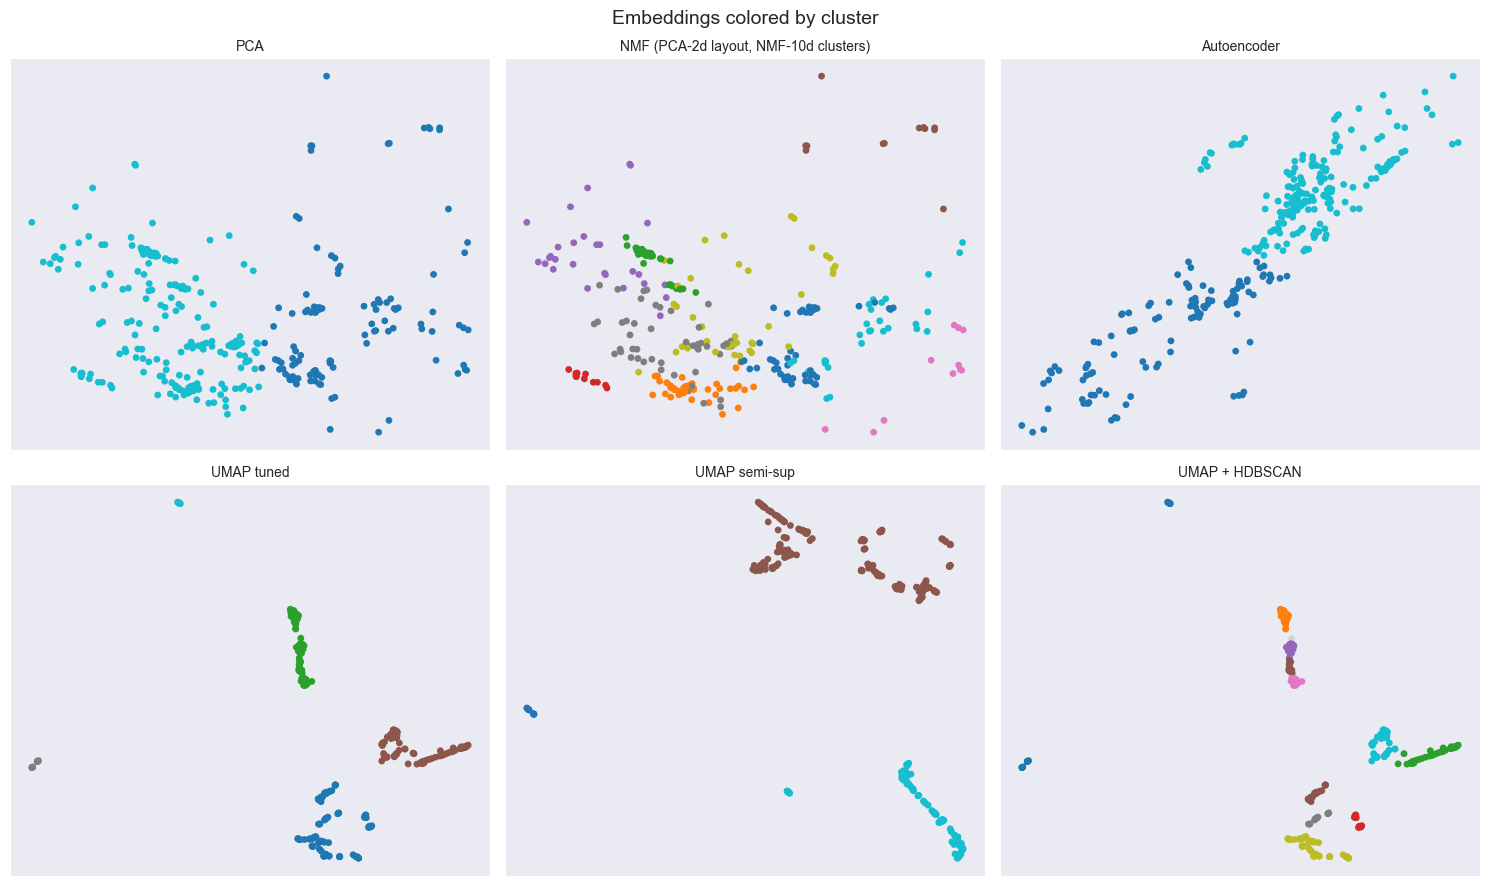

Saved data\embeddings_advanced_grid_kmeans.png


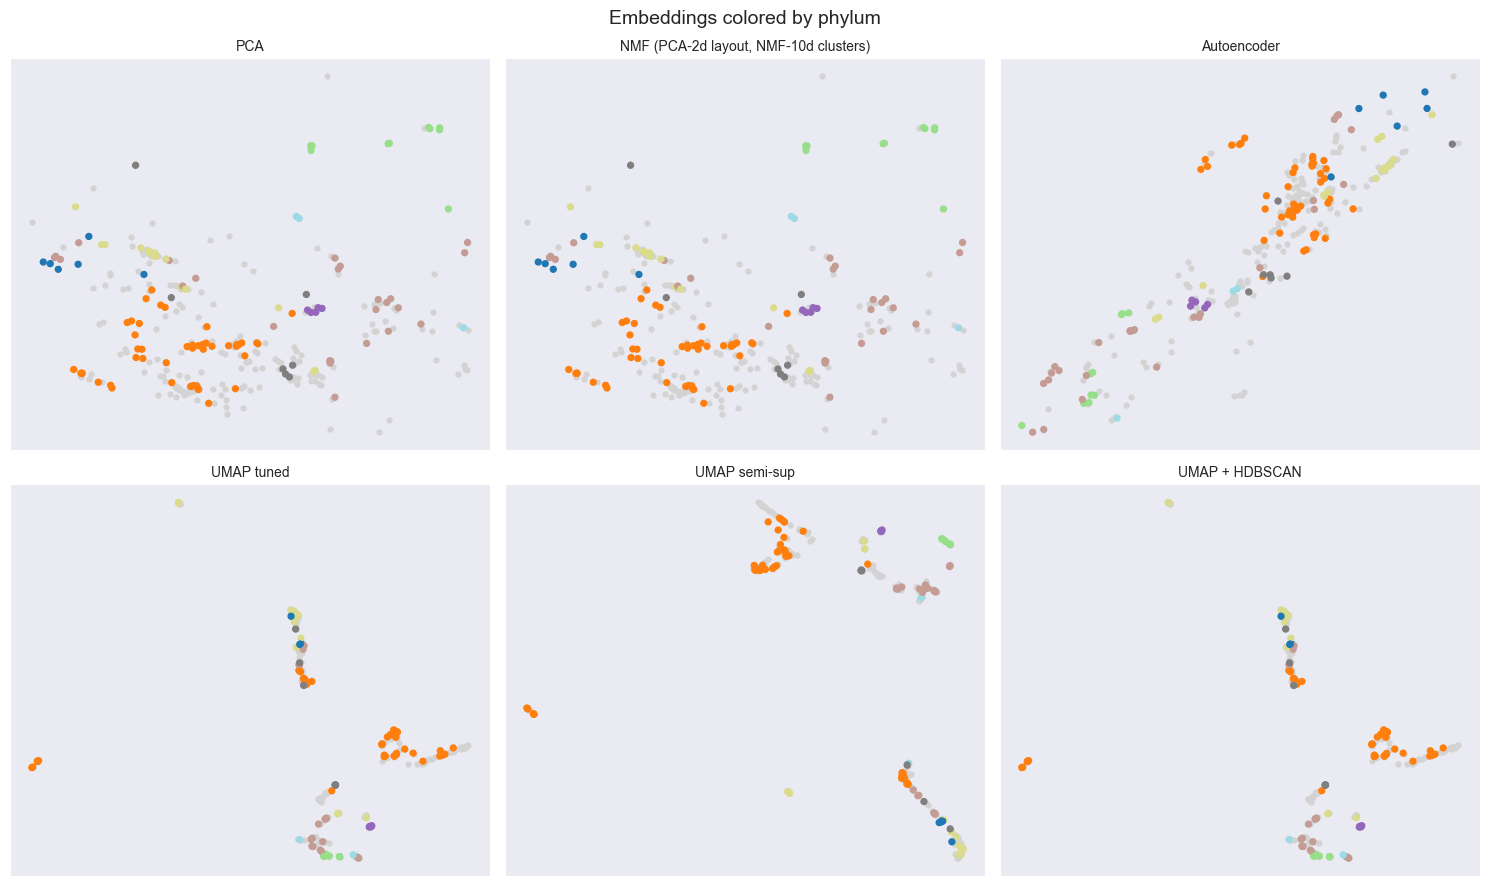

Saved data\embeddings_advanced_grid_phylum.png


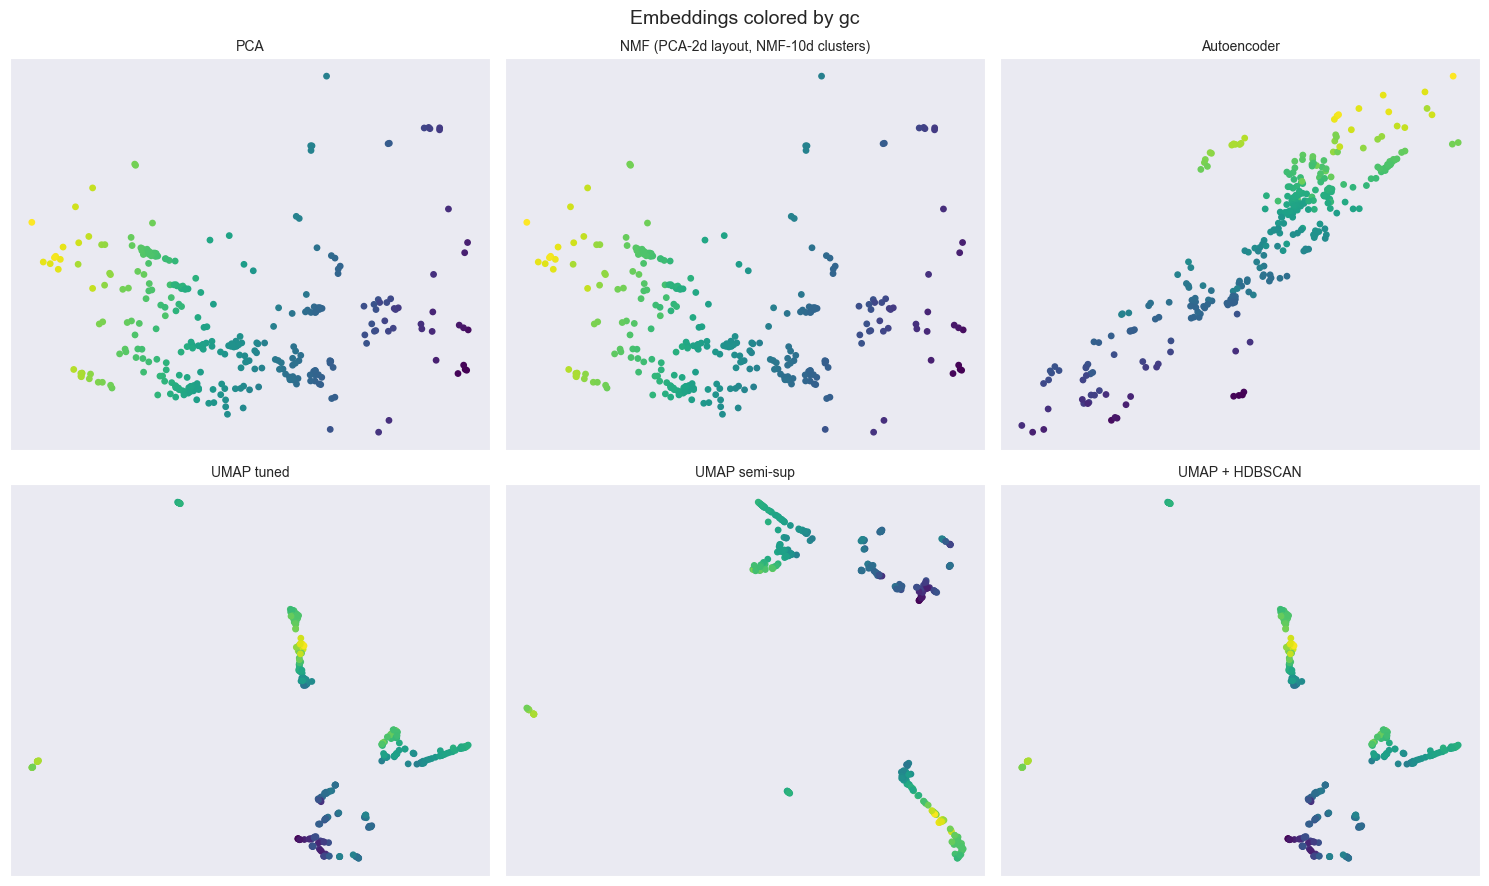

Saved data\embeddings_advanced_grid_gc.png


In [33]:
panels = [
    ("PCA",                                   pca_2,          best_kmeans_labels["PCA-10d"]),
    ("NMF (PCA-2d layout, NMF-10d clusters)", pca_2,          best_kmeans_labels["NMF-10d"]),
    ("Autoencoder",                            ae_2,           best_kmeans_labels["Autoencoder-2d"]),
    ("UMAP tuned",                             umap_tuned_2,   best_kmeans_labels["UMAP-tuned-2d"]),
    ("UMAP semi-sup",                          umap_semisup_2, best_kmeans_labels["UMAP-semisup-2d"]),
    ("UMAP + HDBSCAN",                         umap_tuned_2,   hdb_labels),
]


def draw_grid(panels, color_kind, savepath):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, (title, emb, labels) in zip(axes.flat, panels):
        if color_kind == "cluster":
            if -1 in set(labels):
                m = labels == -1
                ax.scatter(emb[m, 0],  emb[m, 1],  c="lightgray", s=15)
                ax.scatter(emb[~m, 0], emb[~m, 1], c=labels[~m], cmap="tab10", s=15)
            else:
                ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=15)
        elif color_kind == "phylum":
            unlab_ph = np.array([tax_arrays["phylum"][i] is None for i in range(314)])
            ax.scatter(emb[unlab_ph, 0], emb[unlab_ph, 1], c="lightgray", s=12)
            lab_ph = ~unlab_ph
            phyla_for_color = np.array([tax_arrays["phylum"][i] for i in np.where(lab_ph)[0]])
            codes = pd.Series(phyla_for_color).astype("category").cat.codes
            ax.scatter(emb[lab_ph, 0], emb[lab_ph, 1], c=codes, cmap="tab20", s=18)
        elif color_kind == "gc":
            ax.scatter(emb[:, 0], emb[:, 1], c=metadata["gc_content"], cmap="viridis", s=15)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"Embeddings colored by {color_kind}", fontsize=14)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()
    print(f"Saved {savepath}")


draw_grid(panels, "cluster", DATA_DIR / "embeddings_advanced_grid_kmeans.png")
draw_grid(panels, "phylum",  DATA_DIR / "embeddings_advanced_grid_phylum.png")
draw_grid(panels, "gc",      DATA_DIR / "embeddings_advanced_grid_gc.png")

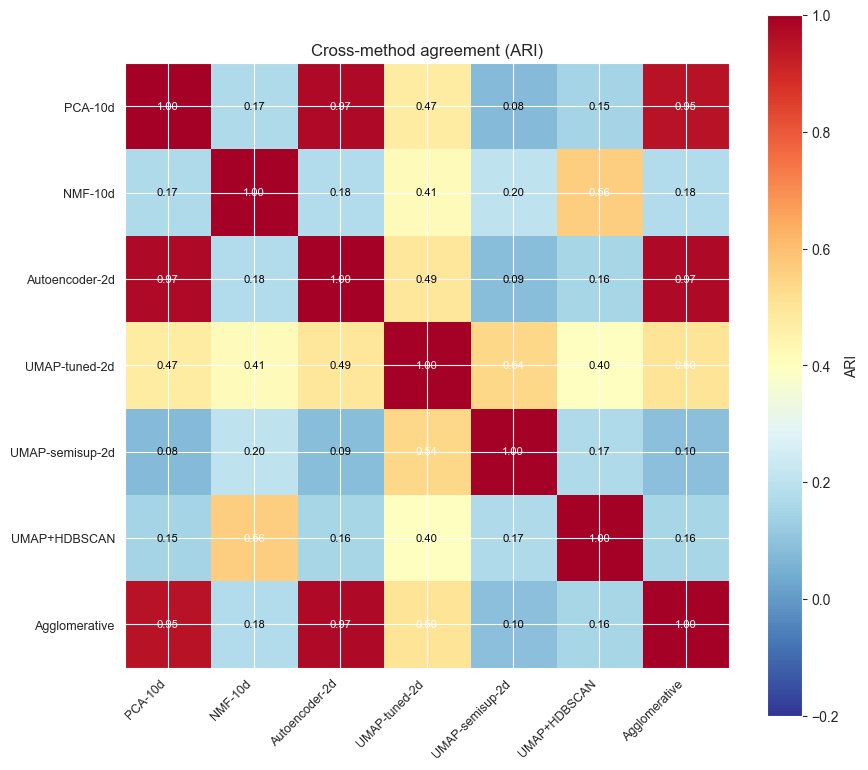

Saved ari_matrix.png


In [34]:
methods_for_ari = list(best_kmeans_labels.keys()) + ["UMAP+HDBSCAN", "Agglomerative"]
ari_labels      = {**best_kmeans_labels, "UMAP+HDBSCAN": hdb_labels, "Agglomerative": best_labels_agg}

n_methods = len(methods_for_ari)
ari_mat   = np.zeros((n_methods, n_methods))
for i, m1 in enumerate(methods_for_ari):
    for j, m2 in enumerate(methods_for_ari):
        ari_mat[i, j] = adjusted_rand_score(ari_labels[m1], ari_labels[m2])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(ari_mat, cmap="RdYlBu_r", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(n_methods)); ax.set_yticks(range(n_methods))
ax.set_xticklabels(methods_for_ari, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(methods_for_ari, fontsize=9)
for i in range(n_methods):
    for j in range(n_methods):
        ax.text(j, i, f"{ari_mat[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(ari_mat[i, j]) > 0.5 else "black", fontsize=8)
plt.colorbar(im, label="ARI")
ax.set_title("Cross-method agreement (ARI)")
plt.tight_layout()
plt.savefig(DATA_DIR / "ari_matrix.png", dpi=150)
plt.show()
print("Saved ari_matrix.png")

### Section 8 — Final Comparison Conclusion

#### Internal vs Taxonomic Silhouette

The most striking finding is the **disconnect between internal and taxonomic silhouette**:

| Method | Internal Sil. | Family Sil. | AMI | Mean Purity |
|---|---|---|---|---|
| NMF-10d (k=10) | 0.380 | **0.274** | **0.648** | **0.778** |
| PCA-10d (k=2) | 0.416 | 0.224 | 0.341 | 0.455 |
| Agglomerative (k=2) | 0.547 | 0.243 | — | — |
| UMAP+HDBSCAN (k=13) | 0.644 | — | — | — |
| UMAP-tuned kmeans (k=5) | 0.723 | 0.138 | 0.519 | 0.739 |
| UMAP-semisup kmeans (k=3) | **0.734** | 0.120 | 0.330 | 0.555 |
| Autoencoder (k=2) | 0.651 | -0.197 | 0.341 | 0.455 |


**Key finding — the disconnect:** UMAP methods have the highest internal silhouette (geometrically clean) but low family silhouette. **NMF has the lowest internal silhouette but wins every biological metric.** High internal silhouette ≠ biological accuracy.

**NMF cluster purity:** Six of ten NMF clusters reached **purity = 1.0** — every labeled MAG inside those clusters belongs to the same bacterial family (Bacteroidaceae, Porphyromonadaceae, Campylobacteraceae, Brachyspiraceae). No other method achieves this.

**Autoencoder confirmed as equivalent to PCA:** ARI between autoencoder and PCA-10d = 0.97. Both found the same trivial k=2 split. The collapsed bottleneck produced meaningless results confirmed by negative family silhouette (-0.197).

**No sample confound:** All methods have sample ARI < 0.06. None of the clustering reflects which sequencing sample a MAG came from — the signal is biology, not batch effects.

**Cross-method groups (ARI heatmap):**
- PCA + Autoencoder + Agglomerative (ARI 0.95–0.97): same coarse GC split (k=2)
- NMF + UMAP+HDBSCAN (ARI=0.56): both find finer structure beyond GC
- UMAP-semisup disagrees with everything (ARI 0.08–0.34): label-guided, not comparable
